# Deep Exploratory Data Analysis (EDA)

This notebook analyzes the IT Support Ticket dataset to find patterns for better classification and priority assignment.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Load Data
df = pd.read_csv("../data/processed/clean_tickets.csv")
df.head()

,clean_text,Ticket Type
0,connection icon icon dear please setup icon pe...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting meeting requesting meeting hi pleas...,Hardware
3,reset passwords external accounts expire days ...,Access
4,mail verification warning hi got attached plea...,Miscellaneous


## 1. Class Distribution Analysis

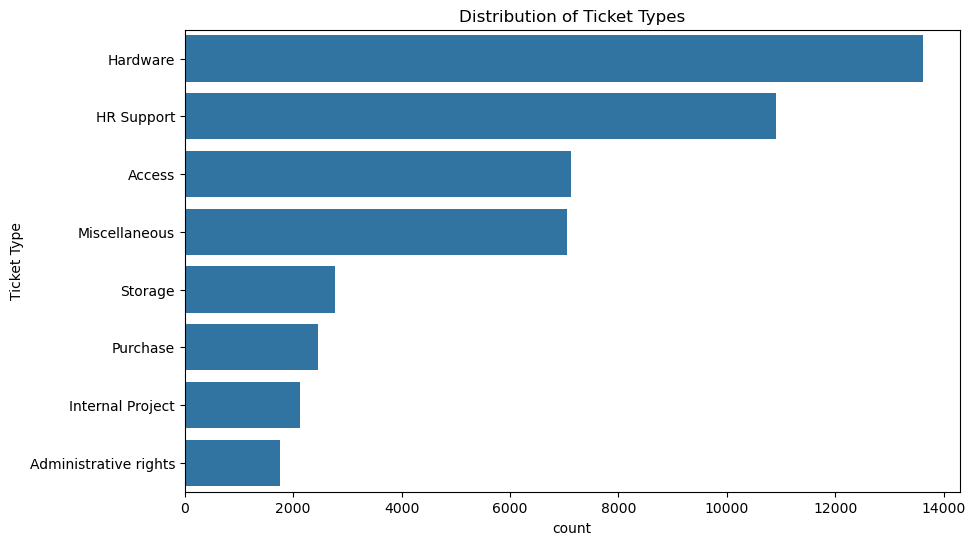

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(y="Ticket Type", data=df, order=df["Ticket Type"].value_counts().index)
plt.title("Distribution of Ticket Types")
plt.show()

## 2. Keyword Analysis per Category
Identify unique words for each category to improve the Rule-Based Priority System.

In [4]:
def get_top_keywords(category, n=15):
    subset = df[df["Ticket Type"] == category]['clean_text'].dropna()
    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(subset)
    
    word_counts = np.array(X.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()
    
    indices = np.argsort(word_counts)[::-1]
    top_words = [(words[i], word_counts[i]) for i in indices[:n]]
    return top_words

categories = df["Ticket Type"].unique()
for cat in categories:
    print(f"\n--- {cat} ---")
    print(get_top_keywords(cat))


--- Hardware ---
[('hi', 9143), ('regards', 9038), ('pm', 7903), ('hello', 7666), ('thank', 7551), ('sent', 6741), ('thanks', 6067), ('access', 4773), ('issue', 4240), ('kind', 4082), ('help', 3927), ('tuesday', 3635), ('best', 3558), ('wednesday', 3413), ('thursday', 3306)]

--- Access ---
[('confluence', 4587), ('pm', 4401), ('hi', 4001), ('regards', 3440), ('hello', 3182), ('thanks', 3150), ('thank', 3097), ('card', 2656), ('user', 2654), ('access', 2643), ('password', 2190), ('license', 1880), ('create', 1700), ('users', 1547), ('kind', 1501)]

--- Miscellaneous ---
[('hi', 4660), ('pm', 4605), ('change', 4390), ('regards', 4116), ('thank', 3866), ('hello', 3405), ('thanks', 3264), ('add', 3197), ('sent', 2297), ('kind', 1920), ('approval', 1708), ('tuesday', 1571), ('wednesday', 1550), ('assigned', 1500), ('best', 1486)]

--- HR Support ---
[('pm', 6477), ('thank', 6192), ('hi', 6092), ('leaver', 5646), ('regards', 5386), ('hello', 5383), ('error', 4778), ('form', 4570), ('starte